<a href="https://colab.research.google.com/github/nicolenelson10/credit-card-fraud-detection-ml/blob/feature%2Frandom-forest/notebooks/03_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

print("ZIP file uploaded successfully!")

Saving archive.zip to archive (2).zip
ZIP file uploaded successfully!


In [ ]:
import zipfile
import os

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir("dataset"))

['creditcard.csv']


In [ ]:
df = pd.read_csv("dataset/creditcard.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (284807, 31)


In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
print("Class Distribution:")
print(df["Class"].value_counts())

print("\nClass Distribution in Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Distribution in Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (284807, 30)
Target shape: (284807,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (227845, 30)
Testing features shape: (56962, 30)
Training target shape: (227845,)
Testing target shape: (56962,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

print("Amount feature scaled successfully!")

Amount feature scaled successfully!


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")


Random Forest model trained successfully!


In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)

Random Forest Results
---------------------
Accuracy : 0.9995084442259752
Precision: 0.9605263157894737
Recall   : 0.7448979591836735
F1-Score : 0.8390804597701149


In [ ]:
print("\nRandom Forest Results (%)")
print("-------------------------")
print(f"Accuracy : {accuracy_rf * 100:.2f}%")
print(f"Precision: {precision_rf * 100:.2f}%")
print(f"Recall   : {recall_rf * 100:.2f}%")
print(f"F1-Score : {f1_rf * 100:.2f}%")


Random Forest Results (%)
-------------------------
Accuracy : 99.95%
Precision: 96.05%
Recall   : 74.49%
F1-Score : 83.91%


In [ ]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[56861     3]
 [   25    73]]


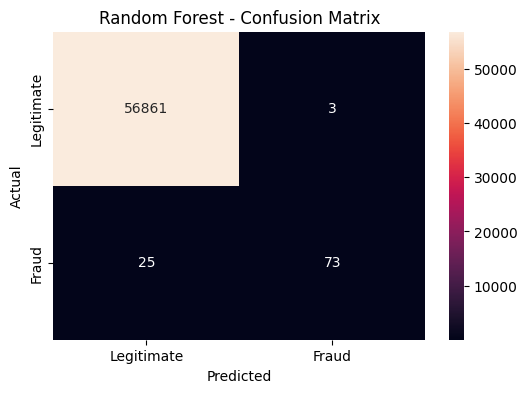

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
rf_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf
    ]
})

rf_results

,Metric,Score
0,Accuracy,0.999508
1,Precision,0.960526
2,Recall,0.744898
3,F1-Score,0.839080


In [ ]:
rf_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score (%)": [
        accuracy_rf * 100,
        precision_rf * 100,
        recall_rf * 100,
        f1_rf * 100
    ]
})

rf_results

,Metric,Score (%)
0,Accuracy,99.950844
1,Precision,96.052632
2,Recall,74.489796
3,F1-Score,83.908046


## Interpretation of Random Forest Results

The Random Forest model was trained and evaluated on the credit card fraud detection dataset.

The model achieved an accuracy of 99.95%, precision of 96.05%, recall of 74.49%, and an F1-score of 83.91%.

Since the dataset is highly imbalanced, accuracy alone is not sufficient to evaluate the model. Precision indicates how many transactions predicted as fraudulent were actually fraudulent, while recall indicates how many actual fraudulent transactions were detected.

The confusion matrix showed 56,861 true negatives, 3 false positives, 25 false negatives, and 73 true positives.

The high precision indicates that the model generated very few false fraud alerts. However, the recall shows that some fraudulent transactions were not detected.

The Random Forest results will be compared with the Logistic Regression results using the same preprocessing and train-test split.